In [1]:
import numpy as np
import gymnasium as gym
import os
import matplotlib.pyplot as plt
import neat
import tqdm

In [2]:
def run_experiment(eval_genomes, config_path, num_runs, num_generations, output_postprocessing):
    config = neat.Config(neat.DefaultGenome, neat.DefaultReproduction,
                         neat.DefaultSpeciesSet, neat.DefaultStagnation,
                         config_path)
    
    history_best_fitness = np.zeros((num_runs, num_generations))
    history_avg_fitness = np.zeros((num_runs, num_generations))
    history_min_fitness = np.zeros((num_runs, num_generations))
    best_genome = None
    max_fitness_ever = -1

    for run_idx in range(num_runs):
        print(f"Run {run_idx + 1}/{num_runs}")
        
        p = neat.Population(config)
        
        for gen in tqdm.tqdm(range(num_generations)):
            winner_of_gen = p.run(eval_genomes, 1)
            
            current_fitnesses = []
            for g in p.population.values():
                if g.fitness is not None:
                    current_fitnesses.append(g.fitness)
            
            history_best_fitness[run_idx, gen] = max(current_fitnesses)
            history_avg_fitness[run_idx, gen] = np.mean(current_fitnesses)
            history_min_fitness[run_idx, gen] = min(current_fitnesses)

            if winner_of_gen.fitness > max_fitness_ever:
                max_fitness_ever = winner_of_gen.fitness
                best_genome = winner_of_gen

    plot_best = np.mean(history_best_fitness, axis=0)
    plot_avg = np.mean(history_avg_fitness, axis=0)
    plot_min = np.mean(history_min_fitness, axis=0)
    return (plot_best, plot_avg, plot_min), best_genome, config

def gym_loop(state, net, env, output_postprocessing):
    done = False
    total_reward = 0
    
    while not done:
        output = net.activate(state)
        output = output_postprocessing(output)
        state, reward, terminated, truncated, info = env.step(output)
        total_reward += reward
        done = terminated or truncated
    
    return total_reward

def create_eval_genomes(gym_name, individual_environment_iterations, output_postprocessing):
    def eval_genomes(genomes, config):
        env = gym.make(gym_name)
        
        for genome_id, genome in genomes:
            net = neat.nn.FeedForwardNetwork.create(genome, config)
            averaged_reward = 0
            
            for _ in range(individual_environment_iterations):
                state, _ = env.reset()
                total_reward = gym_loop(state, net, env, output_postprocessing)
                averaged_reward += total_reward / individual_environment_iterations
                
            genome.fitness = averaged_reward      
        
        env.close()

    return eval_genomes
    
def show_gym(gym_name, winner_genome, config, output_postprocessing):
    env = gym.make(gym_name, render_mode='human')
    net = neat.nn.FeedForwardNetwork.create(winner_genome, config)
    
    state, _ = env.reset()
    total_reward = gym_loop(state, net, env, output_postprocessing)

    print(f"total_reward = {total_reward}")
    env.close()

# CartPole-v1

In [3]:
GYM_NAME = 'CartPole-v1'
NUM_RUNS = 3
GENERATIONS = 10
INDIVIDUAL_ENVIRONMENT_ITERATIONS = 3
CONFIG_PATH = os.path.join('.', 'config-cartpole')
def carpole_output_postprocessing(output):
    return np.argmax(output)

eval_genomes = create_eval_genomes(GYM_NAME, INDIVIDUAL_ENVIRONMENT_ITERATIONS, carpole_output_postprocessing)
(plot_best, plot_avg, plot_min), best_cartpole, config_obj = run_experiment(eval_genomes, CONFIG_PATH, NUM_RUNS, GENERATIONS, carpole_output_postprocessing)

Run 1/3


100%|██████████| 10/10 [00:07<00:00,  1.42it/s]


Run 2/3


100%|██████████| 10/10 [00:07<00:00,  1.27it/s]


Run 3/3


100%|██████████| 10/10 [00:08<00:00,  1.15it/s]


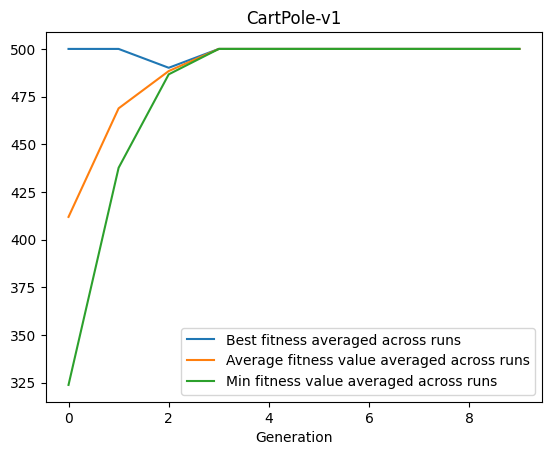

In [4]:
plt.plot(range(GENERATIONS), plot_best, label="Best fitness averaged across runs")
plt.plot(range(GENERATIONS), plot_avg, label="Average fitness value averaged across runs")
plt.plot(range(GENERATIONS), plot_min, label="Min fitness value averaged across runs")
plt.title(GYM_NAME)
plt.xlabel('Generation')
plt.legend()
plt.show()

In [5]:
show_gym(GYM_NAME, best_cartpole, config_obj, carpole_output_postprocessing)

total_reward = 500.0


# BipedalWalker-v3

In [6]:
GYM_NAME = 'BipedalWalker-v3'
NUM_RUNS = 1
GENERATIONS = 30
INDIVIDUAL_ENVIRONMENT_ITERATIONS = 1
CONFIG_PATH = os.path.join('.', 'config-bipedalwalker')

eval_genomes = create_eval_genomes(GYM_NAME, INDIVIDUAL_ENVIRONMENT_ITERATIONS)
(plot_best, plot_avg, plot_min), best_cartpole, config_obj = run_experiment(eval_genomes, CONFIG_PATH, NUM_RUNS, GENERATIONS)

TypeError: create_eval_genomes() missing 1 required positional argument: 'output_postprocessing'

In [ ]:
plt.plot(range(GENERATIONS), plot_best, label="Best fitness averaged across runs")
plt.plot(range(GENERATIONS), plot_avg, label="Average fitness value averaged across runs")
plt.plot(range(GENERATIONS), plot_min, label="Min fitness value averaged across runs")
plt.title(GYM_NAME)
plt.xlabel('Generation')
plt.legend()
plt.show()

In [ ]:
show_gym(GYM_NAME, best_cartpole, config_obj)